**Problem Definition- Build a machine learning solution to predict the market value of a football player using the given features.**

- Imported required libraries

In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')


- Load the dataset

In [212]:
# df=pd.read_csv('/content/player_stats.csv')
df = pd.read_csv('/content/player_stats.csv', encoding='latin1')

In [213]:
df

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000


- conversion

In [214]:
df['value'] = df['value'].astype(str).str.replace(r'[^0-9]', '', regex=True).astype(float)

- checking the information of dataset

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

- check for count of column and row

In [216]:
df.shape

(5682, 41)

- check the statistical summary

In [217]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000,5.682000e+03
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222,2.271115e+06
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154,7.616233e+06
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000,4.000000e+02
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000,3.500000e+04
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000,7.750000e+04
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000,1.600000e+06
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000,1.535000e+08


- check for null

In [218]:
#EDA

df.isnull().sum()

,0
player,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0


- drop the unnecessary columns

In [219]:
df.drop(['player','country','club'],axis=1,inplace=True)

In [220]:
df.columns

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking',
       'slide_tackle', 'stand_tackle', 'aggression', 'reactions',
       'att_position', 'interceptions', 'vision', 'composure', 'crossing',
       'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength',
       'balance', 'sprint_speed', 'agility', 'jumping', 'heading',
       'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties',
       'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

In [221]:
df.shape

(5682, 38)

In [222]:
df['marking'].dtype

dtype('float64')

In [223]:
df['marking']

,marking
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
5677,NaN
5678,NaN
5679,NaN
5680,NaN


- drop the marking column having nulls, column is unnecessary

In [224]:
df.drop('marking', axis=1, inplace=True)

In [225]:
df

,height,weight,age,ball_control,dribbling,slide_tackle,stand_tackle,aggression,reactions,att_position,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,192,84,22,55,43,68,73,72,68,30,...,32,34,41,33,10,11,6,7,9,1400000.0
1,181,80,31,69,70,56,58,62,70,69,...,65,62,48,46,12,15,14,8,14,97500.0
2,193,84,29,25,12,13,16,27,65,17,...,20,15,26,16,64,74,65,68,74,1100000.0
3,187,86,33,46,48,66,69,71,64,48,...,25,13,22,19,10,10,8,14,9,65000.0
4,191,80,23,14,8,14,16,28,50,10,...,9,10,16,5,61,59,62,64,64,30000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,175,71,31,86,88,41,43,63,92,91,...,84,69,86,83,11,14,14,9,14,99500000.0
5678,174,69,31,86,88,38,42,75,91,90,...,77,64,75,75,7,10,10,15,14,101000000.0
5679,175,68,31,94,95,29,32,63,88,86,...,88,87,91,86,15,9,9,15,11,99500000.0
5680,187,83,38,87,81,24,32,62,90,93,...,79,75,90,85,14,7,11,15,11,31000000.0


- checkfor duplicates

In [226]:
df.duplicated().sum()

np.int64(5)

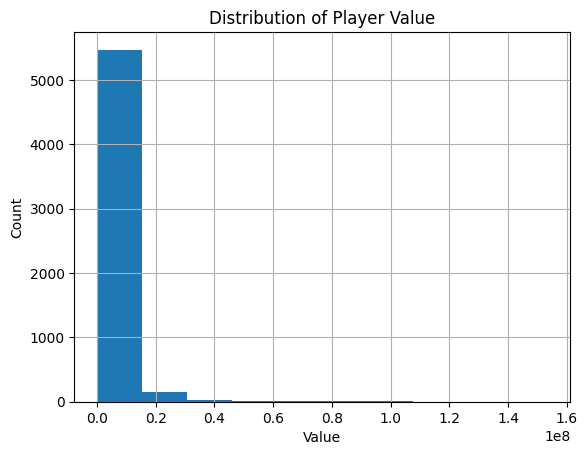

In [227]:
#univariate analysis

df['value'].hist()
plt.title('Distribution of Player Value')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

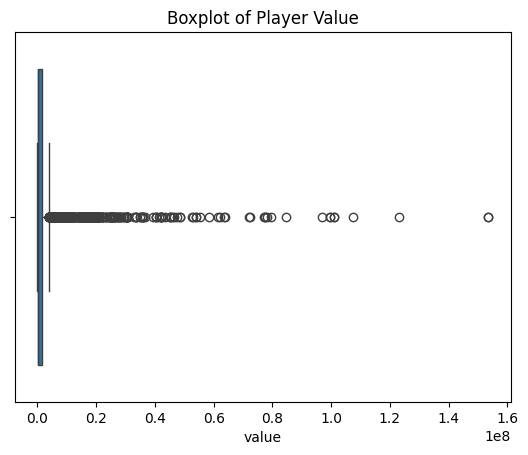

In [228]:
import seaborn as sns

sns.boxplot(x=df['value'])
plt.title('Boxplot of Player Value')
plt.show()

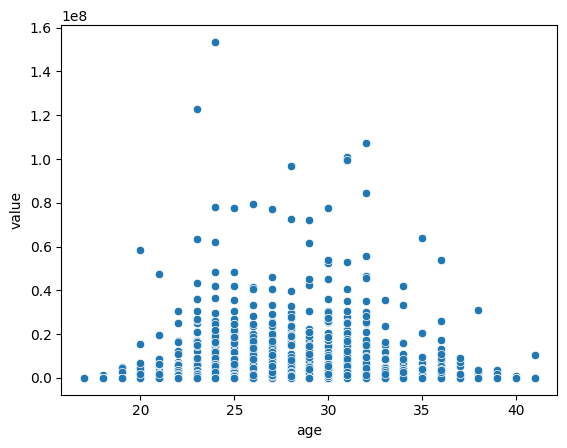

In [229]:
#Bivariate analysis

sns.scatterplot(x='age', y='value', data=df)
plt.show()

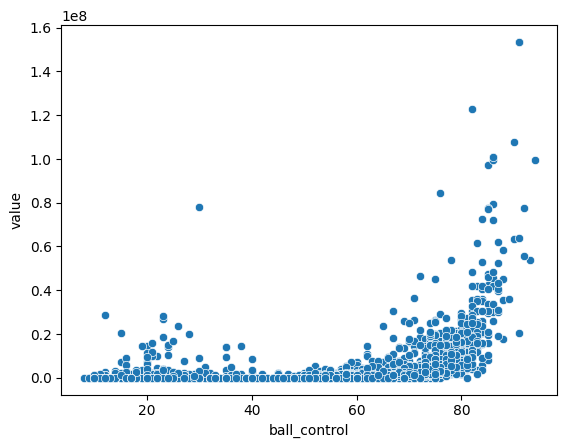

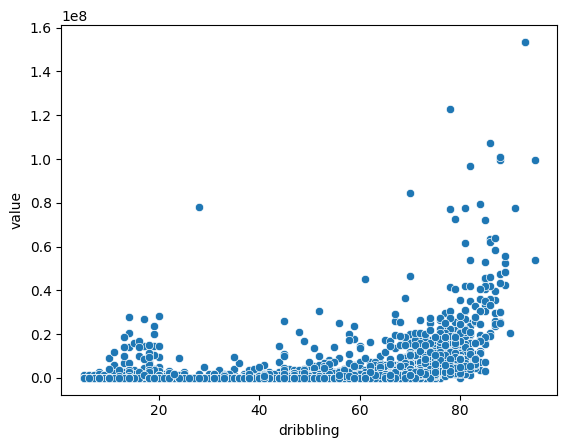

In [230]:
sns.scatterplot(x='ball_control', y='value', data=df)
plt.show()

sns.scatterplot(x='dribbling', y='value', data=df)
plt.show()

In [231]:
df.drop(['gk_diving','gk_handling','gk_kicking','gk_reflexes','gk_positioning'], axis=1, inplace=True)

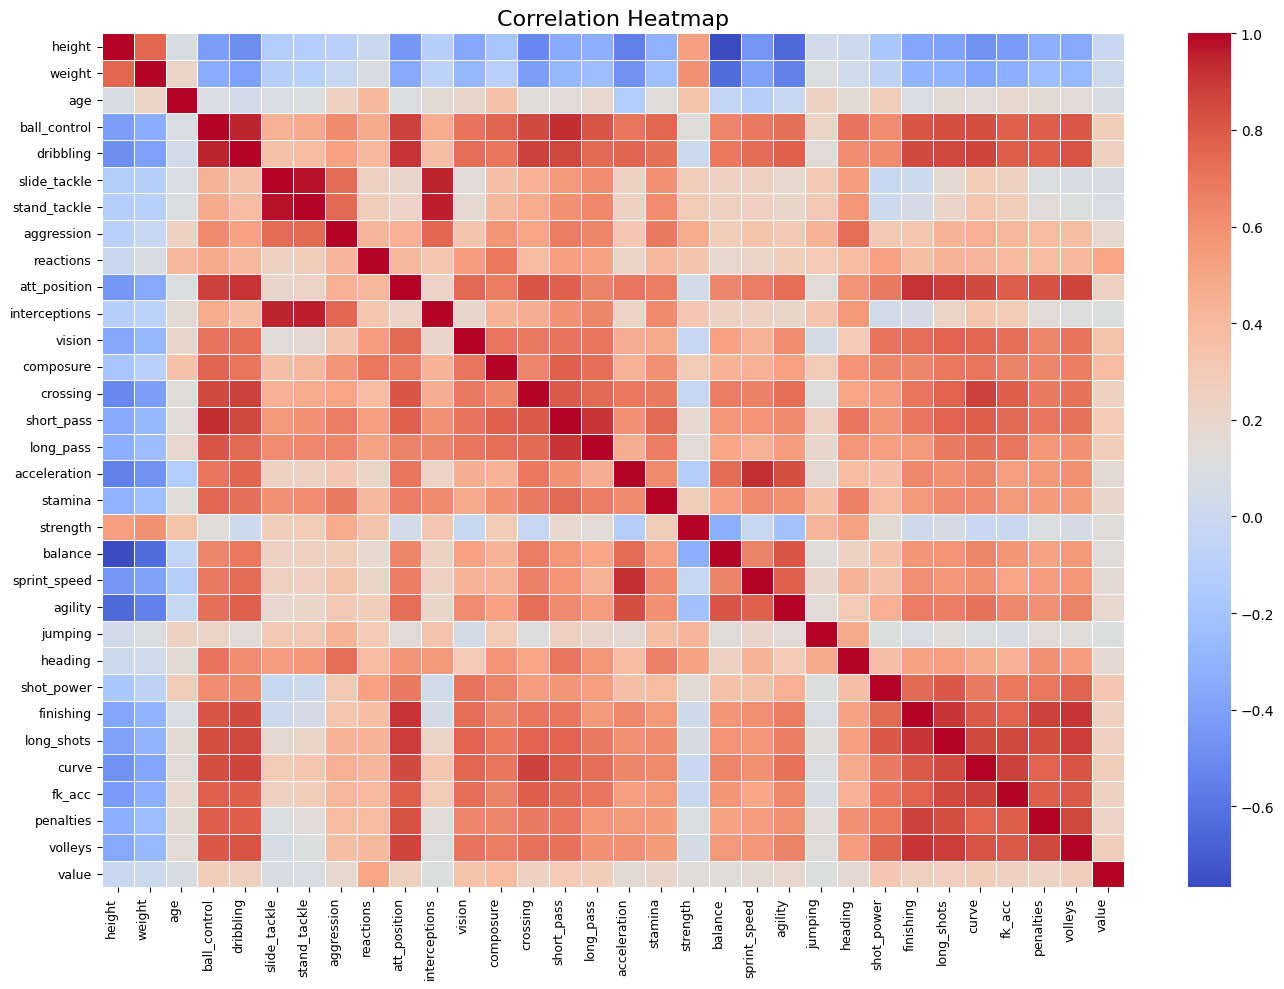

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False,        # True will make it messy
    linewidths=0.5,
    linecolor='white'
)

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()

plt.show()

- detect and remove the outliers

In [233]:
num_df = df.select_dtypes(include=['int64','float64'])

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [234]:
df.shape

(4280, 32)

- log1p: compare the large values


In [235]:
y = np.log1p(df['value'])
X = df.drop('value', axis=1)

- Training and testing the data

In [236]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Standardization

In [237]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- PCA Reduce number of features

In [238]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [239]:
## Explained variance

explained_variance = pca.explained_variance_ratio_

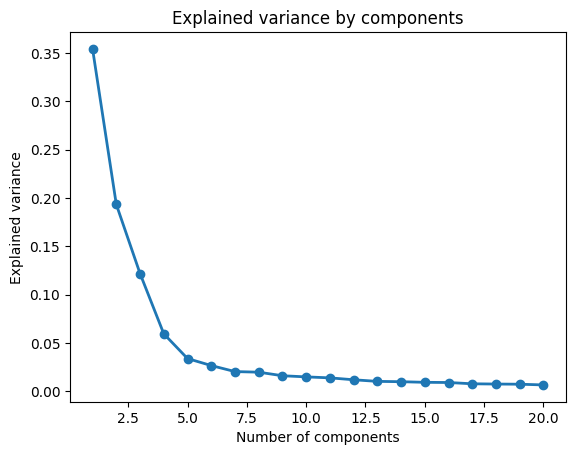

In [240]:
## Plot

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', linewidth=2)
plt.title('Explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.show()

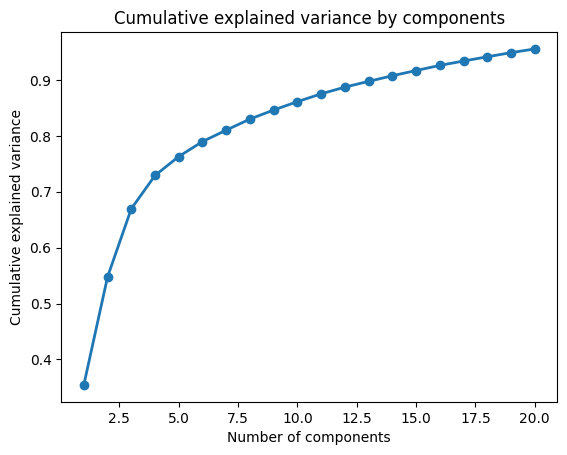

In [241]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-', linewidth=2)
plt.title('Cumulative explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [242]:


n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Optimal number of components: {n_components}")

Optimal number of components: 20


- Model Building

In [243]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_pca, y_train)

LinearRegression()

- Evaluate model

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6691166548174344


- Random Forest model to predict player value

In [245]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("R2:", r2_score(y_test, rf.predict(X_test)))

R2: 0.8225622671111362


In [246]:
bl_model = rf.fit(X_train, y_train)

In [247]:
bl_y_pred = bl_model.predict(X_test)

In [248]:
## Define the parameter grid randomly (trail and error)

param_grid1 = {
    "n_estimators": [100, 150, 50],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

In [249]:
## Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [250]:
## Initialize the GridSearch

grid = GridSearchCV(estimator=rf, param_grid=param_grid1, cv=5)

In [251]:
## Train the gridsearch

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150, 50]})

In [252]:
## Best parameters

print("Best params: ", grid.best_params_)
print("Best CV score: ", grid.best_score_)

Best params:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best CV score:  0.8478544762595479
